# Task 1: Data Understanding and Representation

Dataset: UDPLag.csv  
Objective: To analyze structure, relationships, and reduce dimensionality

In [8]:
#Import librarires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
#load dataset
df = pd.read_csv("UDPLag.csv", low_memory=False)
df.head()

,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,Label
0,186059,172.16.0.5-192.168.50.1-58445-4463-17,172.16.0.5,58445,192.168.50.1,4463,17,2018-12-01 13:04:45.928673,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,UDP-lag
1,135692,172.16.0.5-192.168.50.1-36908-9914-17,172.16.0.5,36908,192.168.50.1,9914,17,2018-12-01 13:04:45.928913,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,UDP-lag
2,33822,172.16.0.5-192.168.50.1-41727-32361-17,172.16.0.5,41727,192.168.50.1,32361,17,2018-12-01 13:04:45.928915,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,UDP-lag
3,24498,172.16.0.5-192.168.50.1-55447-5691-17,172.16.0.5,55447,192.168.50.1,5691,17,2018-12-01 13:04:45.929024,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,UDP-lag
4,117372,172.16.0.5-192.168.50.1-58794-56335-17,172.16.0.5,58794,192.168.50.1,56335,17,2018-12-01 13:04:45.929096,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,UDP-lag


## Dataset Description

- Source: CIC-DDoS2019 Dataset (Kaggle)
- Type: Network traffic dataset for detecting DDoS attacks
- Records: (use df.shape output)
- Attributes: (use df.shape output)
- Objective: To analyze traffic patterns and identify anomalies

In [3]:
# Shape
print("Shape:", df.shape)

# Data types
print("\nData Types:\n", df.dtypes)

# First few rows
df.head()

Shape: (370605, 88)

Data Types:
 Unnamed: 0           int64
Flow ID             object
 Source IP          object
 Source Port         int64
 Destination IP     object
                    ...   
 Idle Max          float64
 Idle Min          float64
SimillarHTTP        object
 Inbound             int64
 Label              object
Length: 88, dtype: object


,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,Label
0,186059,172.16.0.5-192.168.50.1-58445-4463-17,172.16.0.5,58445,192.168.50.1,4463,17,2018-12-01 13:04:45.928673,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,UDP-lag
1,135692,172.16.0.5-192.168.50.1-36908-9914-17,172.16.0.5,36908,192.168.50.1,9914,17,2018-12-01 13:04:45.928913,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,UDP-lag
2,33822,172.16.0.5-192.168.50.1-41727-32361-17,172.16.0.5,41727,192.168.50.1,32361,17,2018-12-01 13:04:45.928915,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,UDP-lag
3,24498,172.16.0.5-192.168.50.1-55447-5691-17,172.16.0.5,55447,192.168.50.1,5691,17,2018-12-01 13:04:45.929024,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,UDP-lag
4,117372,172.16.0.5-192.168.50.1-58794-56335-17,172.16.0.5,58794,192.168.50.1,56335,17,2018-12-01 13:04:45.929096,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,UDP-lag


In [4]:
# Selecting only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Handling missing values BEFORE statistics
numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)
numeric_df = numeric_df.fillna(numeric_df.mean())

# Computing full statistics
summary = pd.DataFrame({
    'min': numeric_df.min(),
    'max': numeric_df.max(),
    'mean': numeric_df.mean(),
    'median': numeric_df.median(),
    'mode': numeric_df.mode().iloc[0],
    'variance': numeric_df.var(),
    'std_dev': numeric_df.std(),
    'skewness': numeric_df.skew(),
    'kurtosis': numeric_df.kurt()
})

summary

,min,max,mean,median,mode,variance,std_dev,skewness,kurtosis
Unnamed: 0,0.0,3.706040e+05,1.853020e+05,185302.0,0.0,1.144570e+10,1.069846e+05,6.787022e-19,-1.200000
Source Port,0.0,6.553200e+04,3.835924e+04,39867.0,672.0,3.173310e+08,1.781379e+04,-2.780898e-01,-1.018205
Destination Port,0.0,6.553500e+04,3.265027e+04,32720.0,53.0,3.641013e+08,1.908144e+04,-9.812237e-03,-1.202123
Protocol,0.0,1.700000e+01,7.502648e+00,6.0,6.0,1.428470e+01,3.779511e+00,2.113412e+00,2.473259
Flow Duration,0.0,1.200000e+08,5.266594e+06,1.0,1.0,1.562694e+14,1.250077e+07,2.489994e+00,7.419219
...,...,...,...,...,...,...,...,...,...
Idle Mean,0.0,9.514679e+07,2.944176e+06,0.0,0.0,4.956014e+13,7.039896e+06,2.536724e+00,6.974626
Idle Std,0.0,3.333886e+07,4.582582e+05,0.0,0.0,2.838195e+12,1.684694e+06,4.912274e+00,29.353026
Idle Max,0.0,9.514679e+07,3.295114e+06,0.0,0.0,6.075230e+13,7.794376e+06,2.359988e+00,5.248056
Idle Min,0.0,9.514679e+07,2.599587e+06,0.0,0.0,4.172091e+13,6.459172e+06,2.917732e+00,10.209327


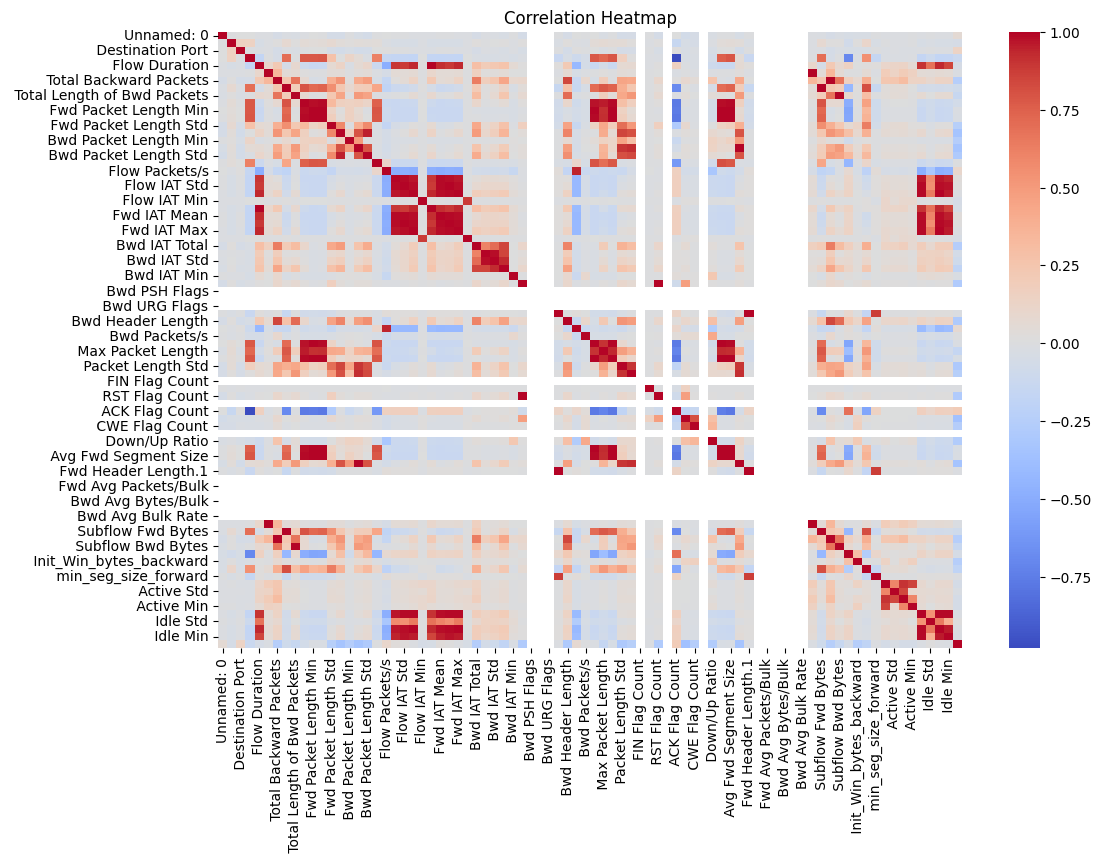

In [5]:
# Correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [6]:
# Convert to matrix (first few rows for simplicity)
matrix = numeric_df.iloc[:5, :5].values

print("Original Matrix:\n", matrix)

# Transpose
print("\nTranspose:\n", matrix.T)

# Addition
print("\nAddition:\n", matrix + matrix)

# Multiplication
print("\nMultiplication:\n", np.dot(matrix, matrix.T))

Original Matrix:
 [[186059  58445   4463     17      1]
 [135692  36908   9914     17      1]
 [ 33822  41727  32361     17      2]
 [ 24498  55447   5691     17      2]
 [117372  58794  56335     17      1]]

Transpose:
 [[186059 135692  33822  24498 117372]
 [ 58445  36908  41727  55447  58794]
 [  4463   9914  32361   5691  56335]
 [    17     17     17     17     17]
 [     1      1      2      2      1]]

Addition:
 [[372118 116890   8926     34      2]
 [271384  73816  19828     34      2]
 [ 67644  83454  64722     34      4]
 [ 48996 110894  11382     34      4]
 [234744 117588 112670     34      2]]

Multiplication:
 [[38053688165 27448052360  8876049447  7824072521 25525755673]
 [27448052360 19872807014  6450262185  5427041357 18654915856]
 [ 8876049447  6450262185  3932304827  3326375069  8246110248]
 [ 7824072521  5427041357  3326375069  3706909587  6455932950]
 [25525755673 18654915856  8246110248  6455932950 20406553335]]


In [7]:
# Handle missing values (important before PCA)
numeric_df = numeric_df.fillna(numeric_df.mean())

# Standardize data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

# Apply PCA
pca = PCA()
pca_data = pca.fit_transform(scaled_data)

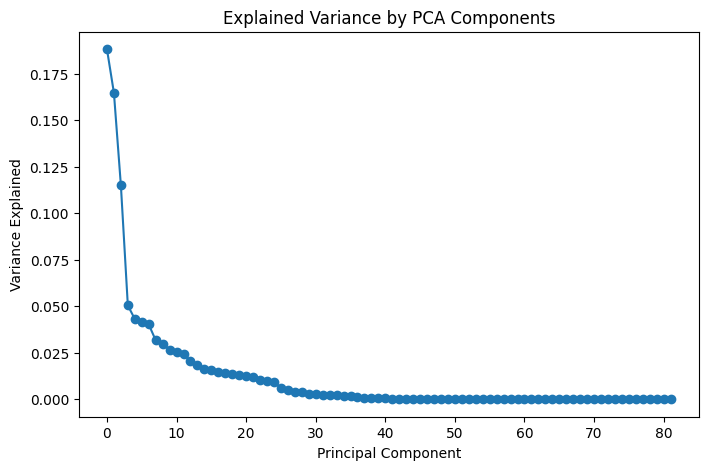

In [8]:
# Variance explained
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(explained_variance, marker='o')
plt.title("Explained Variance by PCA Components")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.show()

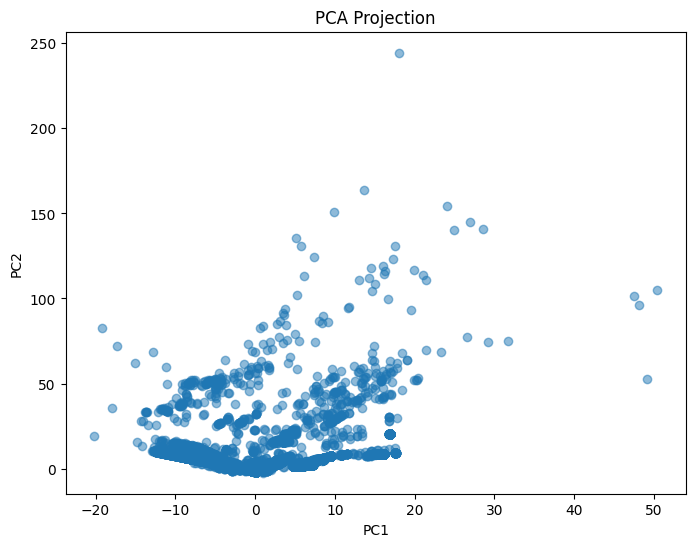

In [9]:
# Plot first 2 components
plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()

## PCA Interpretation

- The first few principal components capture most of the variance.
- This indicates that dimensionality can be reduced without major information loss.
- PCA helps in simplifying the dataset for further analysis and modeling.

# Task 2: Descriptive and Inferential Statistics

Objective:
To summarize data using statistical measures and analyze relationships between variables.

In [10]:
# Using cleaned numeric data from Task 1
numeric_df = df.select_dtypes(include=[np.number])

# Clean again (important for safety)
numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)
numeric_df = numeric_df.fillna(numeric_df.mean())

desc_stats = pd.DataFrame({
    'min': numeric_df.min(),
    'max': numeric_df.max(),
    'mean': numeric_df.mean(),
    'median': numeric_df.median(),
    'mode': numeric_df.mode().iloc[0],
    'variance': numeric_df.var(),
    'std_dev': numeric_df.std(),
    'range': numeric_df.max() - numeric_df.min(),
    'skewness': numeric_df.skew(),
    'kurtosis': numeric_df.kurt()
})

desc_stats

,min,max,mean,median,mode,variance,std_dev,range,skewness,kurtosis
Unnamed: 0,0.0,3.706040e+05,1.853020e+05,185302.0,0.0,1.144570e+10,1.069846e+05,3.706040e+05,6.787022e-19,-1.200000
Source Port,0.0,6.553200e+04,3.835924e+04,39867.0,672.0,3.173310e+08,1.781379e+04,6.553200e+04,-2.780898e-01,-1.018205
Destination Port,0.0,6.553500e+04,3.265027e+04,32720.0,53.0,3.641013e+08,1.908144e+04,6.553500e+04,-9.812237e-03,-1.202123
Protocol,0.0,1.700000e+01,7.502648e+00,6.0,6.0,1.428470e+01,3.779511e+00,1.700000e+01,2.113412e+00,2.473259
Flow Duration,0.0,1.200000e+08,5.266594e+06,1.0,1.0,1.562694e+14,1.250077e+07,1.200000e+08,2.489994e+00,7.419219
...,...,...,...,...,...,...,...,...,...,...
Idle Mean,0.0,9.514679e+07,2.944176e+06,0.0,0.0,4.956014e+13,7.039896e+06,9.514679e+07,2.536724e+00,6.974626
Idle Std,0.0,3.333886e+07,4.582582e+05,0.0,0.0,2.838195e+12,1.684694e+06,3.333886e+07,4.912274e+00,29.353026
Idle Max,0.0,9.514679e+07,3.295114e+06,0.0,0.0,6.075230e+13,7.794376e+06,9.514679e+07,2.359988e+00,5.248056
Idle Min,0.0,9.514679e+07,2.599587e+06,0.0,0.0,4.172091e+13,6.459172e+06,9.514679e+07,2.917732e+00,10.209327


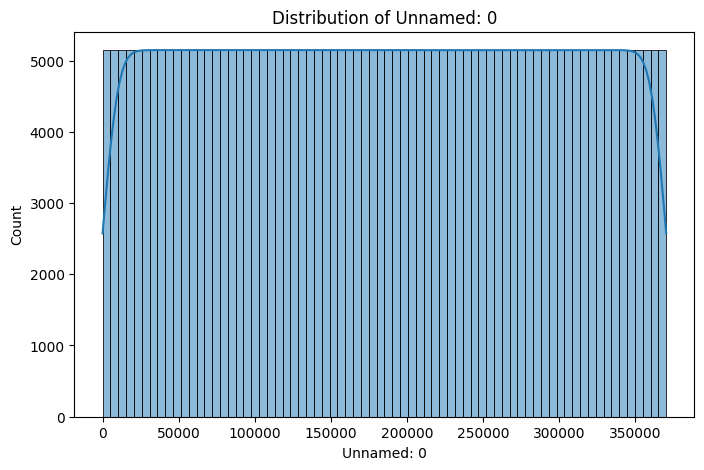

In [11]:
# Selecting one numeric column
col = numeric_df.columns[0]

plt.figure(figsize=(8,5))
sns.histplot(numeric_df[col], kde=True)
plt.title(f"Distribution of {col}")
plt.show()

In [12]:
from scipy.stats import shapiro

# Taking a sample (Shapiro fails on very large data)
sample_data = numeric_df[col].sample(5000, random_state=42)

stat, p_value = shapiro(sample_data)

print("Shapiro Test Statistic:", stat)
print("p-value:", p_value)

if p_value > 0.05:
    print("Data is likely normally distributed")
else:
    print("Data is NOT normally distributed")

Shapiro Test Statistic: 0.9508084679333447
p-value: 5.070487244330629e-38
Data is NOT normally distributed


In [13]:
# Find categorical columns
print(df.select_dtypes(include='object').nunique().sort_values())

 Label                  3
SimillarHTTP           89
 Source IP            117
 Destination IP       138
Flow ID            368680
 Timestamp         370600
dtype: int64


In [15]:
from scipy.stats import ttest_ind

# Manually choose a good categorical column after checking nunique()
cat_col = " Label"   # ⚠️ CHANGE THIS BASED ON YOUR OUTPUT

# Clean data
data = df[[cat_col, col]].copy()
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()

# Get unique categories
groups = data[cat_col].unique()

print("Categories:", groups)

if len(groups) >= 2:
    group1 = data[data[cat_col] == groups[0]][col]
    group2 = data[data[cat_col] == groups[1]][col]

    print("Group 1 size:", len(group1))
    print("Group 2 size:", len(group2))

    stat, p_value = ttest_ind(group1, group2)

    print("t-test statistic:", stat)
    print("p-value:", p_value)

    if p_value < 0.05:
        print("Significant difference between groups")
    else:
        print("No significant difference")
else:
    print("Not enough categories for t-test")

Categories: ['UDP-lag' 'BENIGN' 'WebDDoS']
Group 1 size: 366461
Group 2 size: 3705
t-test statistic: 40.92533386024966
p-value: 0.0
Significant difference between groups


In [16]:
# Select two meaningful numeric columns to check the correlation between them
col1 = numeric_df.columns[2]
col2 = numeric_df.columns[3]

corr = numeric_df[col1].corr(numeric_df[col2])
print(f"Correlation between {col1} and {col2}:", corr)

Correlation between  Destination Port and  Protocol: -0.006464038437974454


In [17]:
#Linear Regression implementation
from sklearn.linear_model import LinearRegression

X = numeric_df[[col1]]
y = numeric_df[col2]

model = LinearRegression()
model.fit(X, y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R^2 Score:", model.score(X, y))

Slope: -1.2803492716069603e-06
Intercept: 7.544452117808277
R^2 Score: 4.178379293040546e-05


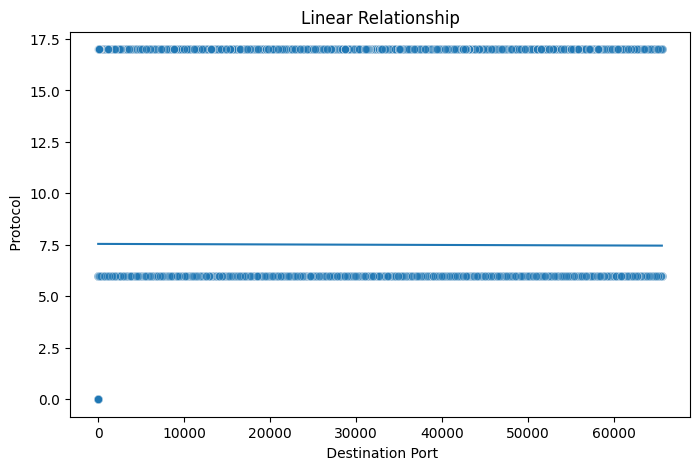

In [18]:
#Linear Regression plot
plt.figure(figsize=(8,5))

# Scatter plot
sns.scatterplot(x=numeric_df[col1], y=numeric_df[col2], alpha=0.3)

# Predictions
y_pred = model.predict(X)

# Sort values for smooth line
sorted_idx = np.argsort(numeric_df[col1].values)

plt.plot(
    numeric_df[col1].values[sorted_idx],
    y_pred[sorted_idx],
)

plt.title("Linear Relationship")
plt.xlabel(col1)
plt.ylabel(col2)
plt.show()

## Interpretation

- Descriptive statistics summarize the dataset's distribution and variability.
- The histogram shows the distribution of a selected numeric variable.
- The Shapiro test indicates whether the data follows a normal distribution.
- The t-test compares the means between two meaningful groups (based on a categorical label).
- Correlation and regression analysis show the strength and direction of relationships between variables.

# Task 3: Data Preprocessing

Objective:
To clean, transform, and prepare the dataset for analysis by handling missing values, encoding, normalization, and reduction.

In [19]:
# Creating a copy of original dataset
df_clean = df.copy()

In [20]:
# Check missing values
missing_before = df_clean.isnull().sum()

# Replace inf values
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

# Fill numeric missing values with mean
num_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].mean())

# Fill categorical missing values with mode
cat_cols = df_clean.select_dtypes(include='object').columns
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

missing_after = df_clean.isnull().sum()

print("Missing Before:\n", missing_before.head())
print("\nMissing After:\n", missing_after.head())

Missing Before:
 Unnamed: 0         0
Flow ID            0
 Source IP         0
 Source Port       0
 Destination IP    0
dtype: int64

Missing After:
 Unnamed: 0         0
Flow ID            0
 Source IP         0
 Source Port       0
 Destination IP    0
dtype: int64


In [21]:
# Check duplicates
print("Duplicates before:", df_clean.duplicated().sum())

# Remove duplicates
df_clean = df_clean.drop_duplicates()

print("Duplicates after:", df_clean.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


In [22]:
# Standardizing categorical values (lowercase + strip spaces)
for col in cat_cols:
    df_clean[col] = df_clean[col].str.lower().str.strip()

df_clean.head()

,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,Label
0,186059,172.16.0.5-192.168.50.1-58445-4463-17,172.16.0.5,58445,192.168.50.1,4463,17,2018-12-01 13:04:45.928673,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,udp-lag
1,135692,172.16.0.5-192.168.50.1-36908-9914-17,172.16.0.5,36908,192.168.50.1,9914,17,2018-12-01 13:04:45.928913,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,udp-lag
2,33822,172.16.0.5-192.168.50.1-41727-32361-17,172.16.0.5,41727,192.168.50.1,32361,17,2018-12-01 13:04:45.928915,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,udp-lag
3,24498,172.16.0.5-192.168.50.1-55447-5691-17,172.16.0.5,55447,192.168.50.1,5691,17,2018-12-01 13:04:45.929024,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,udp-lag
4,117372,172.16.0.5-192.168.50.1-58794-56335-17,172.16.0.5,58794,192.168.50.1,56335,17,2018-12-01 13:04:45.929096,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,udp-lag


## Data Integration

Since only a single dataset (UDPLag.csv) is used, no data merging or integration was required.

In [23]:
#Data Transformation aka Normalization/Transformation
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = df_clean.copy()

df_scaled[num_cols] = scaler.fit_transform(df_clean[num_cols])

df_scaled.head()

,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,Label
0,0.007076,172.16.0.5-192.168.50.1-58445-4463-17,172.16.0.5,1.127541,192.168.50.1,-1.477211,2.512855,2018-12-01 13:04:45.928673,-0.421302,-0.041701,...,-0.035985,-0.041151,-0.028744,-0.418214,-0.272013,-0.422756,-0.402465,0,0.103221,udp-lag
1,-0.463712,172.16.0.5-192.168.50.1-36908-9914-17,172.16.0.5,-0.081468,192.168.50.1,-1.191540,2.512855,2018-12-01 13:04:45.928913,-0.421302,-0.041701,...,-0.035985,-0.041151,-0.028744,-0.418214,-0.272013,-0.422756,-0.402465,0,0.103221,udp-lag
2,-1.415907,172.16.0.5-192.168.50.1-41727-32361-17,172.16.0.5,0.189054,192.168.50.1,-0.015160,2.512855,2018-12-01 13:04:45.928915,-0.421302,-0.041701,...,-0.035985,-0.041151,-0.028744,-0.418214,-0.272013,-0.422756,-0.402465,0,0.103221,udp-lag
3,-1.503060,172.16.0.5-192.168.50.1-55447-5691-17,172.16.0.5,0.959245,192.168.50.1,-1.412855,2.512855,2018-12-01 13:04:45.929024,-0.421302,-0.041701,...,-0.035985,-0.041151,-0.028744,-0.418214,-0.272013,-0.422756,-0.402465,0,0.103221,udp-lag
4,-0.634952,172.16.0.5-192.168.50.1-58794-56335-17,172.16.0.5,1.147133,192.168.50.1,1.241246,2.512855,2018-12-01 13:04:45.929096,-0.421302,-0.041701,...,-0.035985,-0.041151,-0.028744,-0.418214,-0.272013,-0.422756,-0.402465,0,0.103221,udp-lag


In [24]:
# Identify high-cardinality categorical columns before encoding categorical values
high_card_cols = [col for col in cat_cols if df_clean[col].nunique() > 50]

print("Dropping high-cardinality columns:", high_card_cols)

# Drop them
df_reduced = df_scaled.drop(columns=high_card_cols)

# Remaining categorical columns
remaining_cat_cols = df_reduced.select_dtypes(include='object').columns

print("Encoding columns:", remaining_cat_cols)

# One-hot encoding only safe columns
df_encoded = pd.get_dummies(df_reduced, columns=remaining_cat_cols, drop_first=True)

df_encoded.head()

Dropping high-cardinality columns: ['Flow ID', ' Source IP', ' Destination IP', ' Timestamp', 'SimillarHTTP']
Encoding columns: Index([' Label'], dtype='object')


,Unnamed: 0,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Inbound,Label_udp-lag,Label_webddos
0,0.007076,1.127541,-1.477211,2.512855,-0.421302,-0.041701,-0.134722,0.818639,-0.015818,1.465982,...,-0.035985,-0.041151,-0.028744,-0.418214,-0.272013,-0.422756,-0.402465,0.103221,True,False
1,-0.463712,-0.081468,-1.191540,2.512855,-0.421302,-0.041701,-0.134722,0.836023,-0.015818,1.493961,...,-0.035985,-0.041151,-0.028744,-0.418214,-0.272013,-0.422756,-0.402465,0.103221,True,False
2,-1.415907,0.189054,-0.015160,2.512855,-0.421302,-0.041701,-0.134722,0.795462,-0.015818,1.428677,...,-0.035985,-0.041151,-0.028744,-0.418214,-0.272013,-0.422756,-0.402465,0.103221,True,False
3,-1.503060,0.959245,-1.412855,2.512855,-0.421302,-0.041701,-0.134722,0.778079,-0.015818,1.400698,...,-0.035985,-0.041151,-0.028744,-0.418214,-0.272013,-0.422756,-0.402465,0.103221,True,False
4,-0.634952,1.147133,1.241246,2.512855,-0.421302,-0.041701,-0.134722,0.795462,-0.015818,1.428677,...,-0.035985,-0.041151,-0.028744,-0.418214,-0.272013,-0.422756,-0.402465,0.103221,True,False


In [25]:
#Data reduction using PCA
from sklearn.decomposition import PCA

# Using only numeric data after encoding
X = df_encoded

# Reduce to 5 components (you can change)
pca = PCA(n_components=5)

X_reduced = pca.fit_transform(X)

print("Reduced shape:", X_reduced.shape)

Reduced shape: (370605, 5)


In [26]:
# Data discretization
# Select a numeric column
col = num_cols[0]

# Create bins
df_clean[col + "_binned"] = pd.cut(df_clean[col], bins=3, labels=["Low", "Medium", "High"])

df_clean[[col, col + "_binned"]].head()

,Unnamed: 0,Unnamed: 0_binned
0,186059,Medium
1,135692,Medium
2,33822,Low
3,24498,Low
4,117372,Low


In [27]:
#Comparison before vs after pre-processing
print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape)

print("\nOriginal Missing Values:", df.isnull().sum().sum())
print("After Cleaning Missing Values:", df_clean.isnull().sum().sum())

Original Shape: (370605, 88)
Cleaned Shape: (370605, 89)

Original Missing Values: 36132
After Cleaning Missing Values: 0


## Summary of Preprocessing

- Missing values were handled using mean (numeric) and mode (categorical).
- Duplicate records were removed.
- Categorical inconsistencies were standardized.
- Numerical features were normalized using StandardScaler.
- Categorical variables were encoded using one-hot encoding.
- Dimensionality was reduced using PCA.
- Continuous data was discretized into categories.

These steps improve data quality and prepare it for further analysis and modeling.

# Task 4: Exploratory Data Analysis (EDA)

Objective:
To visually and statistically explore the dataset to identify patterns, relationships, and anomalies.

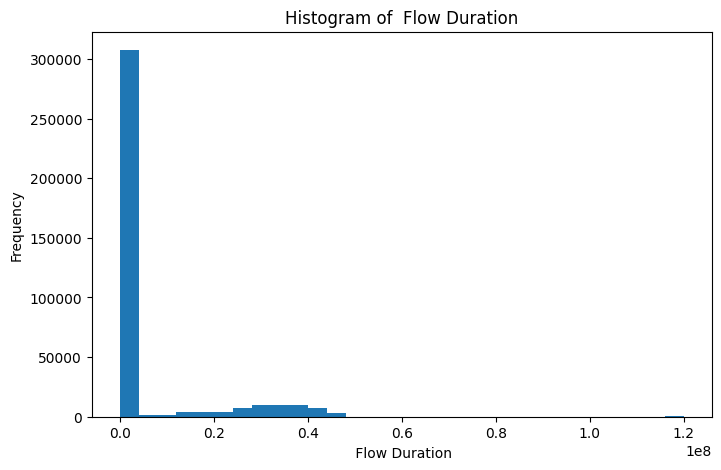

In [28]:
# Select a numeric column
col = numeric_df.columns[4]

plt.figure(figsize=(8,5))
plt.hist(numeric_df[col], bins=30)
plt.title(f"Histogram of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

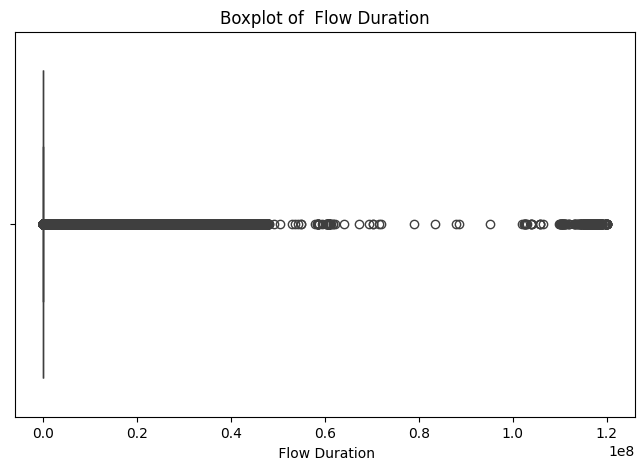

In [29]:
#Box plot
plt.figure(figsize=(8,5))
sns.boxplot(x=numeric_df[col])
plt.title(f"Boxplot of {col}")
plt.show()

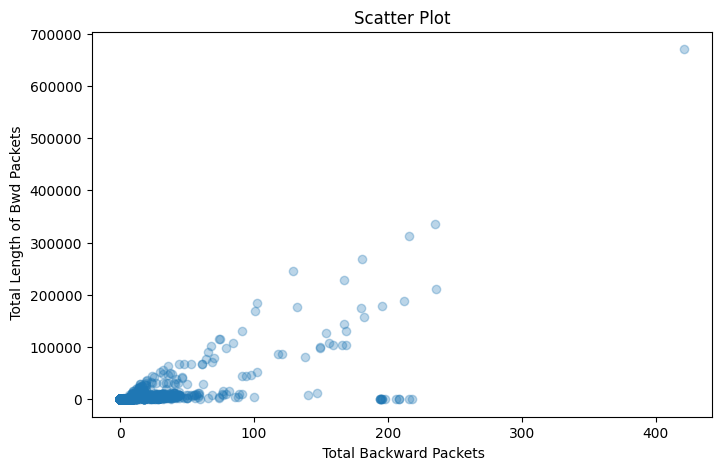

In [30]:
#Scatter Plot
col1 = numeric_df.columns[6]
col2 = numeric_df.columns[8]

plt.figure(figsize=(8,5))
plt.scatter(numeric_df[col1], numeric_df[col2], alpha=0.3)
plt.xlabel(col1)
plt.ylabel(col2)
plt.title("Scatter Plot")
plt.show()

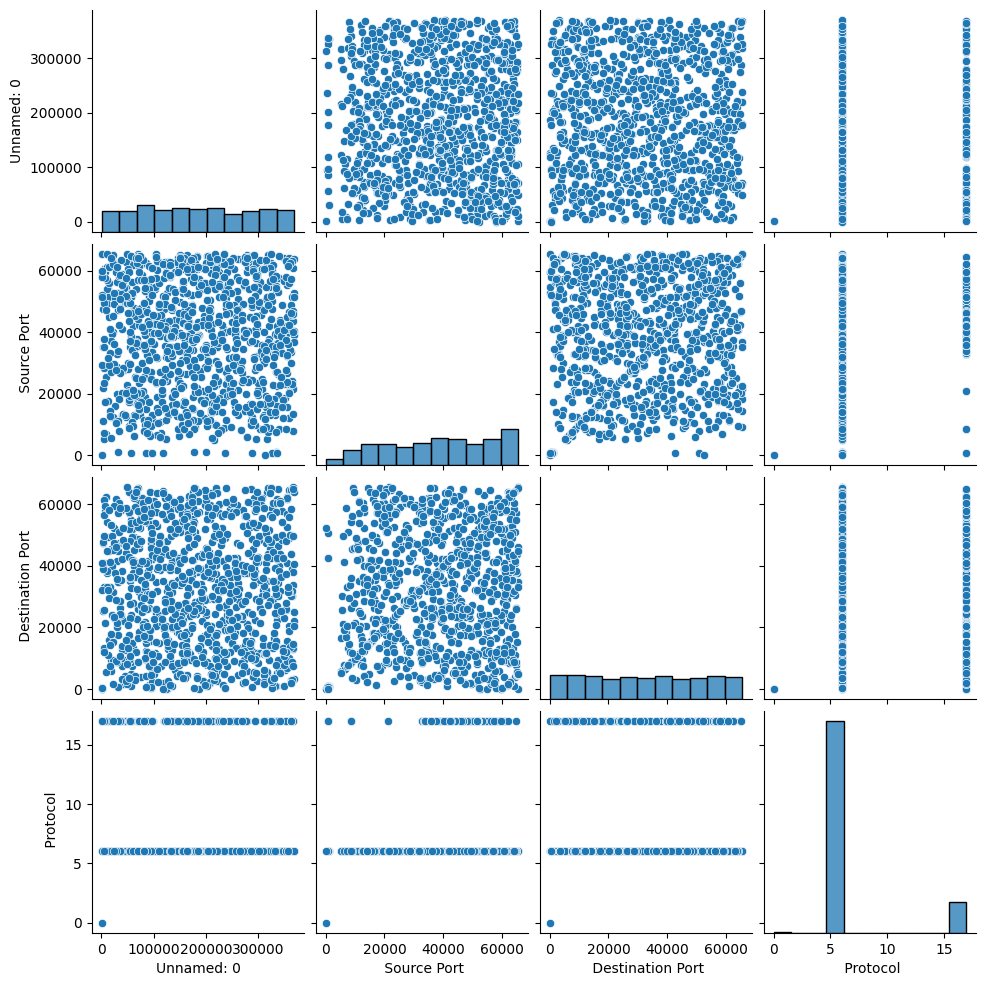

In [31]:
# Pair Plot (optimized)

# Select only a few important numeric columns (first 4–5)
selected_cols = numeric_df.columns[:4]

# Take a small sample
sample_df = numeric_df[selected_cols].sample(1000, random_state=42)

# Pairplot on reduced data
sns.pairplot(sample_df)

plt.show()

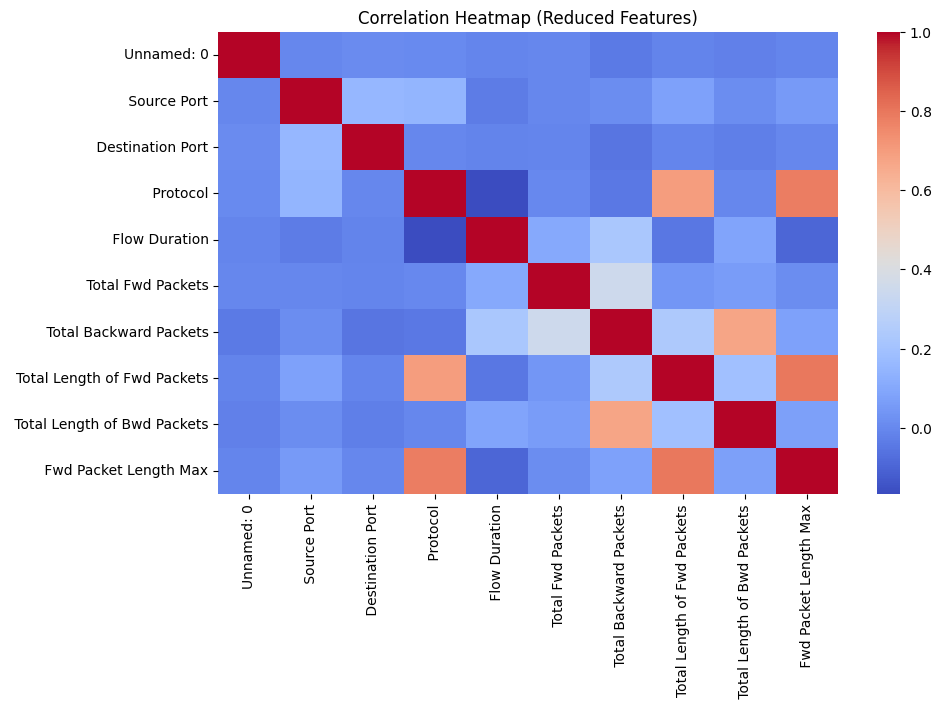

In [32]:
# Heatmap (optimized)

#Select a only a few first columns
selected_cols = numeric_df.columns[:10]
corr_matrix = numeric_df[selected_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, cmap='coolwarm')

plt.title("Correlation Heatmap (Reduced Features)")
plt.show()

## Observations

- The pair plot provides a comprehensive view of relationships between multiple numerical features.
- Diagonal plots indicate the distribution of each variable, while off-diagonal plots show pairwise relationships.
- Some variables exhibit linear patterns, suggesting correlation, while others appear scattered, indicating weak or no relationship.
- The heatmap clearly visualizes correlation strength between features.
- Strong positive correlations are observed where values increase together, while negative correlations indicate inverse relationships.
- Several features show weak correlation, implying independence.

These observations help in identifying important variables and relationships for further analysis and modeling.

## Analytical Summary

The exploratory data analysis (EDA) provided significant insights into the structure and behavior of the dataset. The distribution of numerical variables indicates that several features are skewed and contain outliers, which is common in real-world network traffic data. These outliers may correspond to abnormal or attack-related activities.

The pair plot revealed relationships between multiple variables, showing that some features exhibit linear trends, while others appear more dispersed, indicating weak correlations. This suggests that not all variables contribute equally to explaining the data patterns.

The correlation heatmap further highlighted the strength of relationships among variables. Certain features show strong positive or negative correlations, which can be useful for feature selection and dimensionality reduction.

Overall, the dataset demonstrates complex patterns typical of network traffic, including variability, correlations, and anomalies. These insights are valuable for understanding the data and will assist in building more effective analytical and predictive models in subsequent stages.

# Task 5: Reflection

Working on this dataset helped us understand the complete flow of a data science project, starting from data understanding to preprocessing, analysis, and visualization. As a group, we realized how important it is to first explore the dataset properly before applying any techniques. While working on data cleaning, we encountered missing values, inconsistent entries, and duplicates, which showed us how messy real-world data can be.

One of the main challenges we faced was handling the size and complexity of the dataset. Some operations, especially encoding and visualization, were computationally expensive and even caused memory issues. To deal with this, we used techniques like sampling and reducing the number of features, which helped us complete the tasks efficiently.

Overall, this assignment gave us a better understanding of how different stages of data science are connected. It also helped us improve our problem-solving approach and teamwork while working with real-world data.